# Linear Regression — Salary Prediction

In this module, we will build and test Linear Regression models using a real-world salary dataset from Kaggle.

We will cover:

1. Simple Linear Regression
2. Train/Test Split
3. Model Training
4. Predictions
5. Regression Line
6. MAE, MSE, RMSE and R²
7. Residual Analysis
8. Multiple Linear Regression
9. Model Comparison
10. Testing the models with new inputs

### Dataset

Kaggle Dataset:
`abhishek14398/salary-dataset-simple-linear-regression`

### Problem

Predict an employee's salary based on their years of experience.

**Input (X):** YearsExperience

**Target (y):** Salary

## Install Kaggle API

We will use the Kaggle API to download the dataset directly into Google Colab.

In [1]:
!pip install -q kaggle

In [2]:
import os
from getpass import getpass

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("Libraries imported successfully.")

Libraries imported successfully.


## Kaggle API Authentication

We will enter the Kaggle API token using `getpass()`.

The token will not be displayed while entering it.

We will store it as an environment variable instead of writing the token directly into the notebook.

In [3]:
kaggle_token = getpass("Enter your Kaggle API token: ")

os.environ["KAGGLE_API_TOKEN"] = kaggle_token

del kaggle_token

print("Kaggle API token configured successfully.")

Enter your Kaggle API token: ··········
Kaggle API token configured successfully.


## Download the Dataset

We will download the following Kaggle dataset:

`abhishek14398/salary-dataset-simple-linear-regression`

The dataset will be extracted directly into the Colab environment.

In [4]:
!mkdir -p /content/salary_dataset

!kaggle datasets download \
    -d abhishek14398/salary-dataset-simple-linear-regression \
    -p /content/salary_dataset \
    --unzip

Dataset URL: https://www.kaggle.com/datasets/abhishek14398/salary-dataset-simple-linear-regression
License(s): CC0-1.0
100% 457/457 [00:00<00:00, 568kB/s]



In [5]:
os.listdir("/content/salary_dataset")

['Salary_dataset.csv']

## Load Dataset

We will use Pandas to read the CSV file into a DataFrame.

The DataFrame will be stored in the variable `df`.

In [6]:
dataset_path = "/content/salary_dataset/Salary_dataset.csv"

df = pd.read_csv(dataset_path)

df.head()

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0


#Inspect the Dataset

In [7]:
print("Dataset Shape:", df.shape)

Dataset Shape: (30, 3)


In [8]:
print("Columns:")
print(df.columns.tolist())

Columns:
['Unnamed: 0', 'YearsExperience', 'Salary']


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       30 non-null     int64  
 1   YearsExperience  30 non-null     float64
 2   Salary           30 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 852.0 bytes


In [10]:
df.describe()

,Unnamed: 0,YearsExperience,Salary
count,30.000000,30.000000,30.000000
mean,14.500000,5.413333,76004.000000
std,8.803408,2.837888,27414.429785
min,0.000000,1.200000,37732.000000
25%,7.250000,3.300000,56721.750000
50%,14.500000,4.800000,65238.000000
75%,21.750000,7.800000,100545.750000
max,29.000000,10.600000,122392.000000


#Check Data Quality

## Basic Data Quality Check

Before training the model, we will check:

- Missing values
- Duplicate rows
- Data types

In [11]:
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Missing Values:
Unnamed: 0         0
YearsExperience    0
Salary             0
dtype: int64

Duplicate Rows:
0


Remove ID Column

The dataset contains an ID column. It is only an identifier and should not be used as a feature.

In [12]:
if "ID" in df.columns:
    df = df.drop(columns=["ID"])

df.head()

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0


#Verify Final Dataset

In [13]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Shape: (30, 3)

Columns:
['Unnamed: 0', 'YearsExperience', 'Salary']

Data Types:
Unnamed: 0           int64
YearsExperience    float64
Salary             float64
dtype: object


## Define Features and Target

We are solving a salary prediction problem.

### Feature — X

`YearsExperience`

This is the input given to the model.

### Target — y

`Salary`

This is the value we want the model to predict.

The mathematical relationship is:

**y = mx + b**

In our case:

**Salary = m × YearsExperience + b**

In [14]:
X = df[["YearsExperience"]]
y = df["Salary"]

print("X:")
display(X.head())

print("\ny:")
display(y.head())

X:


,YearsExperience
0,1.2
1,1.4
2,1.6
3,2.1
4,2.3



y:


,Salary
0,39344.0
1,46206.0
2,37732.0
3,43526.0
4,39892.0


#Check X and y Dimensions

In [15]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (30, 1)
y shape: (30,)


#Quick Visualization

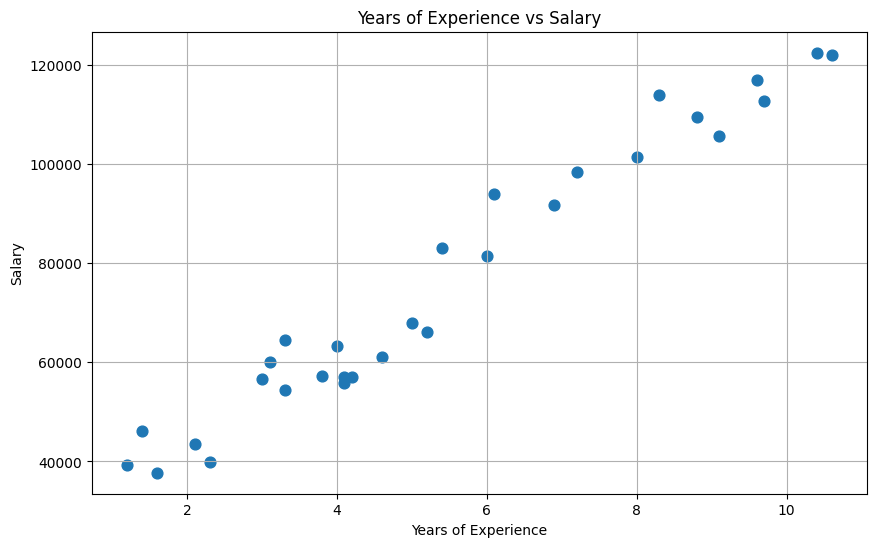

In [17]:
plt.figure(figsize=(10, 6))

plt.scatter(
    X["YearsExperience"],
    y,
    s=60
)

plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Years of Experience vs Salary")

plt.grid(True)
plt.legend
plt.show()

#Correlation

In [18]:
correlation = df["YearsExperience"].corr(df["Salary"])

print("Correlation:", correlation)

Correlation: 0.9782416184887599


In [19]:
print("========== DATASET CHECK ==========")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Features:", X.columns.tolist())
print("Target:", y.name)
print("Missing values:", df.isnull().sum().sum())
print("Duplicates:", df.duplicated().sum())
print("Correlation:", correlation)
print("====================================")

========== DATASET CHECK ==========
Rows: 30
Columns: 3
Features: ['YearsExperience']
Target: Salary
Missing values: 0
Duplicates: 0
Correlation: 0.9782416184887599


Kaggle
   ↓
API Authentication
   ↓
Dataset Download
   ↓
Pandas DataFrame
   ↓
Data Cleaning
   ↓
X = YearsExperience
y = Salary
   ↓
Ready for Model Training

# Train/Test Split

We should not train and evaluate a model on exactly the same data.

We divide our dataset into:

- **Training data:** Used to learn the relationship.
- **Testing data:** Used to evaluate how the model performs on unseen data.

We will use:

- 80% → Training
- 20% → Testing

The model will learn the equation:

**y = mx + b**

where `m` is the coefficient/slope and `b` is the intercept.

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 24
Testing samples: 6


#Inspect Training Data


In [21]:
print("X_train:")
display(X_train.head())

print("\ny_train:")
display(y_train.head())

X_train:


,YearsExperience
28,10.4
24,8.8
12,4.1
0,1.2
4,2.3



y_train:


,Salary
28,122392.0
24,109432.0
12,56958.0
0,39344.0
4,39892.0


#Inspect Testing Data

In [22]:
print("X_test:")
display(X_test)

print("\ny_test:")
display(y_test)

X_test:


,YearsExperience
27,9.7
15,5.0
23,8.3
17,5.4
8,3.3
9,3.8



y_test:


,Salary
27,112636.0
15,67939.0
23,113813.0
17,83089.0
8,64446.0
9,57190.0


# Creating the Model

We will use Scikit-learn's `LinearRegression` class.

The model will learn the best values for:

**m → coefficient/slope**

**b → intercept**

The resulting equation will be:

**ŷ = mx + b**

where `ŷ` represents the predicted salary.

In [23]:
model = LinearRegression()

print(model)

LinearRegression()


#. Train the Model

In [24]:
model.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


## Model Coefficient

The coefficient tells us how much the predicted salary changes when YearsExperience increases by 1 unit.

For our model:

**m = model.coef_**

In [25]:
m = model.coef_[0]

print("Slope (m):", m)

Slope (m): 9423.815323030976


###Get the Intercept

In [26]:
b = model.intercept_

print("Intercept (b):", b)

Intercept (b): 24380.201479473704


#Display the Learned Equation

In [27]:
print(f"Regression Equation:")
print(f"Salary = {m:.2f} × YearsExperience + {b:.2f}")

Regression Equation:
Salary = 9423.82 × YearsExperience + 24380.20


# Predictions

Now that the model has learned the relationship, we can give it the unseen test data.

The model will calculate:

**ŷ = mx + b**

for every value in `X_test`.

In [28]:
y_pred = model.predict(X_test)

print("Predictions:")
print(y_pred)

Predictions:
[115791.21011287  71499.27809463 102597.86866063  75268.80422384
  55478.79204548  60190.69970699]


##Compare Actual vs Predicted

In [29]:
comparison = pd.DataFrame({
    "YearsExperience": X_test["YearsExperience"].values,
    "Actual Salary": y_test.values,
    "Predicted Salary": y_pred
})

comparison

,YearsExperience,Actual Salary,Predicted Salary
0,9.7,112636.0,115791.210113
1,5.0,67939.0,71499.278095
2,8.3,113813.0,102597.868661
3,5.4,83089.0,75268.804224
4,3.3,64446.0,55478.792045
5,3.8,57190.0,60190.699707


# Prediction Error

For every prediction, we can calculate the residual:

**Residual = Actual − Predicted**

A residual tells us how far the prediction was from the actual value.

In [30]:
comparison["Error"] = (
    comparison["Actual Salary"] -
    comparison["Predicted Salary"]
)

comparison["Absolute Error"] = comparison["Error"].abs()

comparison

,YearsExperience,Actual Salary,Predicted Salary,Error,Absolute Error
0,9.7,112636.0,115791.210113,-3155.210113,3155.210113
1,5.0,67939.0,71499.278095,-3560.278095,3560.278095
2,8.3,113813.0,102597.868661,11215.131339,11215.131339
3,5.4,83089.0,75268.804224,7820.195776,7820.195776
4,3.3,64446.0,55478.792045,8967.207955,8967.207955
5,3.8,57190.0,60190.699707,-3000.699707,3000.699707


##Visualize Actual vs Predicted

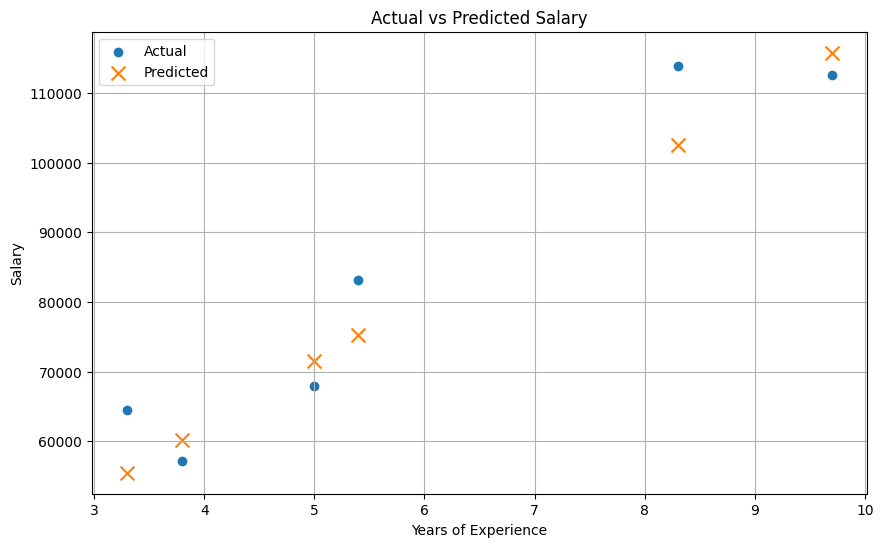

In [31]:
plt.figure(figsize=(10, 6))

plt.scatter(
    X_test["YearsExperience"],
    y_test,
    label="Actual"
)

plt.scatter(
    X_test["YearsExperience"],
    y_pred,
    marker="x",
    s=100,
    label="Predicted"
)

plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Actual vs Predicted Salary")

plt.legend()
plt.grid(True)

plt.show()

##Plot the Regression Line

In [32]:
x_line = np.linspace(
    X["YearsExperience"].min(),
    X["YearsExperience"].max(),
    100
).reshape(-1, 1)

y_line = model.predict(x_line)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


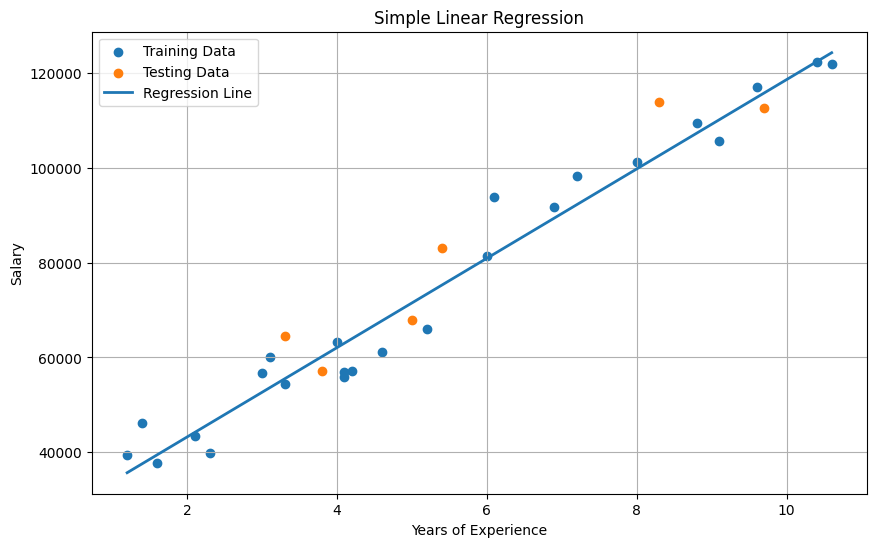

In [33]:
plt.figure(figsize=(10, 6))

plt.scatter(
    X_train["YearsExperience"],
    y_train,
    label="Training Data"
)

plt.scatter(
    X_test["YearsExperience"],
    y_test,
    label="Testing Data"
)

plt.plot(
    x_line,
    y_line,
    linewidth=2,
    label="Regression Line"
)

plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Simple Linear Regression")

plt.legend()
plt.grid(True)

plt.show()

# Interpreting the Regression Line

The regression line represents the relationship learned from the training data.

The model has learned:

**Salary = m × YearsExperience + b**

The:

- **Slope (`m`)** determines how quickly predicted salary increases.
- **Intercept (`b`)** represents the predicted salary when YearsExperience = 0.

The actual observations do not necessarily fall directly on the line.

The vertical distance between an observation and the line represents its prediction error/residual.

##Test One New Employee

In [34]:
new_employee = pd.DataFrame({
    "YearsExperience": [5]
})

predicted_salary = model.predict(new_employee)

print(
    f"Predicted salary for 5 years of experience: "
    f"₹{predicted_salary[0]:,.2f}"
)

Predicted salary for 5 years of experience: ₹71,499.28


#Test Multiple New Employees

In [35]:
new_employees = pd.DataFrame({
    "YearsExperience": [1, 3, 5, 7, 10]
})

predicted_salaries = model.predict(new_employees)

predictions = new_employees.copy()
predictions["Predicted Salary"] = predicted_salaries

predictions

,YearsExperience,Predicted Salary
0,1,33804.016803
1,3,52651.647449
2,5,71499.278095
3,7,90346.908741
4,10,118618.354710


##Create a Prediction Function

In [36]:
def predict_salary(years_experience):
    input_data = pd.DataFrame({
        "YearsExperience": [years_experience]
    })

    prediction = model.predict(input_data)[0]

    return prediction

In [37]:
years = 8

salary_prediction = predict_salary(years)

print(
    f"Predicted salary for {years} years of experience: "
    f"₹{salary_prediction:,.2f}"
)

Predicted salary for 8 years of experience: ₹99,770.72


##Test the Function

In [38]:
test_experience = [2, 4, 6, 8, 10, 12]

for years in test_experience:
    salary = predict_salary(years)

    print(
        f"{years:>2} years → ₹{salary:,.2f}"
    )

 2 years → ₹43,227.83
 4 years → ₹62,075.46
 6 years → ₹80,923.09
 8 years → ₹99,770.72
10 years → ₹118,618.35
12 years → ₹137,465.99


In [39]:
print("========== MODEL CHECK ==========")

print(f"Slope (m): {m:.2f}")
print(f"Intercept (b): {b:.2f}")

print("\nRegression Equation:")
print(f"Salary = {m:.2f} × YearsExperience + {b:.2f}")

print("\nTraining Samples:", len(X_train))
print("Testing Samples:", len(X_test))

print("=================================")

========== MODEL CHECK ==========
Slope (m): 9423.82
Intercept (b): 24380.20

Regression Equation:
Salary = 9423.82 × YearsExperience + 24380.20

Training Samples: 24
Testing Samples: 6


# Part 2 Complete

We have now:

- Split the dataset into training and testing sets.
- Created a `LinearRegression` model.
- Trained the model.
- Learned the slope and intercept.
- Obtained the regression equation.
- Predicted salaries for test data.
- Compared actual and predicted values.
- Visualized the regression line.
- Tested the model with new inputs.

Next, we will properly **evaluate the model** using:

- MAE
- MSE
- RMSE
- R² Score

and then visualize the residuals.

# Model Evaluation

A model can make predictions, but we need to measure how accurate those predictions are.

We will use four common regression metrics:

1. MAE — Mean Absolute Error
2. MSE — Mean Squared Error
3. RMSE — Root Mean Squared Error
4. R² — R-Squared Score

We will calculate all metrics using the **test dataset**, not the training dataset.

## Mean Absolute Error (MAE)

MAE calculates the average absolute difference between actual and predicted values.

Formula:

MAE = (1/n) Σ |y - ŷ|

Lower MAE is better.

If MAE = ₹3,000, the model's predictions are off by approximately ₹3,000 on average.

In [40]:
mae = mean_absolute_error(y_test, y_pred)

print(f"MAE: ₹{mae:,.2f}")

MAE: ₹6,286.45


## Mean Squared Error (MSE)

MSE calculates the average squared prediction error.

Formula:

MSE = (1/n) Σ(y - ŷ)²

Because errors are squared, larger errors receive more penalty.

Lower MSE is better.

In [41]:
mse = mean_squared_error(y_test, y_pred)

print(f"MSE: {mse:,.2f}")

MSE: 49,830,096.86


## Root Mean Squared Error (RMSE)

RMSE is the square root of MSE.

RMSE = √MSE

Unlike MSE, RMSE is expressed in the same unit as the target.

Since our target is Salary, RMSE is expressed in ₹.

Lower RMSE is better.

In [42]:
rmse = np.sqrt(mse)

print(f"RMSE: ₹{rmse:,.2f}")

RMSE: ₹7,059.04


## R² Score

R² measures how much of the variation in the target variable is explained by the model.

A higher R² generally indicates a better fit.

For example:

R² = 0.90

means the model explains approximately 90% of the variance in the target for the evaluated data.

R² can also be negative when a model performs worse than a simple baseline prediction.

In [43]:
r2 = r2_score(y_test, y_pred)

print(f"R² Score: {r2:.4f}")
print(f"R² Score (%): {r2 * 100:.2f}%")

R² Score: 0.9024
R² Score (%): 90.24%


##Calculate All Metrics Together

In [44]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

metrics = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R²"],
    "Value": [mae, mse, rmse, r2]
})

metrics

,Metric,Value
0,MAE,6.286454e+03
1,MSE,4.983010e+07
2,RMSE,7.059044e+03
3,R²,9.024462e-01


#Display Metrics Clearly

In [45]:
print("=" * 40)
print("LINEAR REGRESSION MODEL EVALUATION")
print("=" * 40)

print(f"MAE  : ₹{mae:,.2f}")
print(f"MSE  : {mse:,.2f}")
print(f"RMSE : ₹{rmse:,.2f}")
print(f"R²   : {r2:.4f}")
print("=" * 40)

LINEAR REGRESSION MODEL EVALUATION
MAE  : ₹6,286.45
MSE  : 49,830,096.86
RMSE : ₹7,059.04
R²   : 0.9024


## Actual vs Predicted

Let's inspect every prediction made on the test dataset.

We will calculate:

**Error = Actual − Predicted**

and:

**Absolute Error = |Actual − Predicted|**

In [46]:
results = pd.DataFrame({
    "YearsExperience": X_test["YearsExperience"].values,
    "Actual Salary": y_test.values,
    "Predicted Salary": y_pred
})

results["Error"] = (
    results["Actual Salary"] -
    results["Predicted Salary"]
)

results["Absolute Error"] = results["Error"].abs()

results = results.sort_values("YearsExperience")

results

,YearsExperience,Actual Salary,Predicted Salary,Error,Absolute Error
4,3.3,64446.0,55478.792045,8967.207955,8967.207955
5,3.8,57190.0,60190.699707,-3000.699707,3000.699707
1,5.0,67939.0,71499.278095,-3560.278095,3560.278095
3,5.4,83089.0,75268.804224,7820.195776,7820.195776
2,8.3,113813.0,102597.868661,11215.131339,11215.131339
0,9.7,112636.0,115791.210113,-3155.210113,3155.210113


#Percentage Error

In [47]:
results["Percentage Error"] = (
    results["Absolute Error"] /
    results["Actual Salary"]
) * 100

results

,YearsExperience,Actual Salary,Predicted Salary,Error,Absolute Error,Percentage Error
4,3.3,64446.0,55478.792045,8967.207955,8967.207955,13.914297
5,3.8,57190.0,60190.699707,-3000.699707,3000.699707,5.246896
1,5.0,67939.0,71499.278095,-3560.278095,3560.278095,5.240404
3,5.4,83089.0,75268.804224,7820.195776,7820.195776,9.411830
2,8.3,113813.0,102597.868661,11215.131339,11215.131339,9.853999
0,9.7,112636.0,115791.210113,-3155.210113,3155.210113,2.801245


#Find the Best and Worst Prediction

In [48]:
best_prediction = results.loc[
    results["Absolute Error"].idxmin()
]

worst_prediction = results.loc[
    results["Absolute Error"].idxmax()
]

print("Best Prediction:")
display(best_prediction.to_frame().T)

print("\nWorst Prediction:")
display(worst_prediction.to_frame().T)

Best Prediction:


,YearsExperience,Actual Salary,Predicted Salary,Error,Absolute Error,Percentage Error
5,3.8,57190.0,60190.699707,-3000.699707,3000.699707,5.246896



Worst Prediction:


,YearsExperience,Actual Salary,Predicted Salary,Error,Absolute Error,Percentage Error
2,8.3,113813.0,102597.868661,11215.131339,11215.131339,9.853999


#Actual vs Predicted Plot

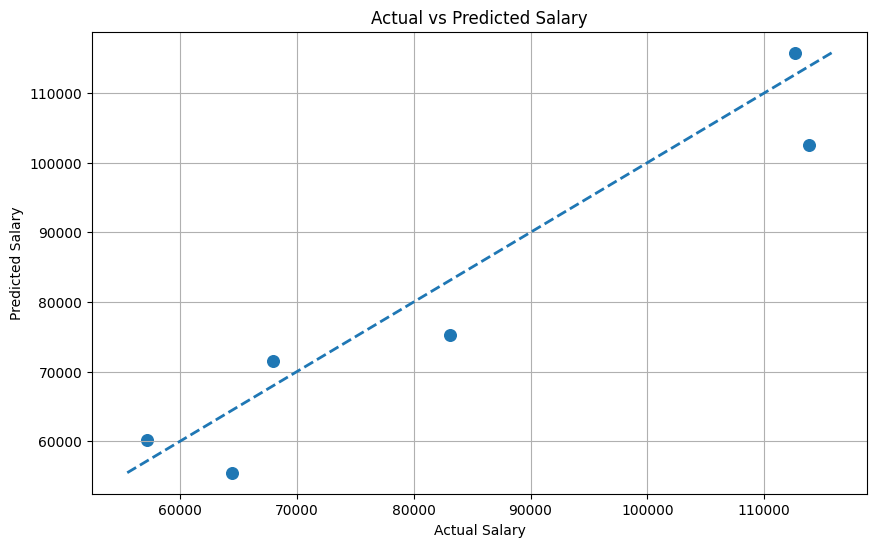

In [49]:
plt.figure(figsize=(10, 6))

plt.scatter(
    y_test,
    y_pred,
    s=70
)

# Perfect prediction line
min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    linewidth=2
)

plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary")

plt.grid(True)
plt.show()

## How to Read This Plot

The dashed diagonal line represents:

**Predicted = Actual**

If a prediction lies exactly on this line:

**Actual Salary = Predicted Salary**

The closer the points are to the diagonal line, the better the predictions are.

##Residual Calculation

# Residual Analysis

A residual is the difference between the actual value and the predicted value.

Residual:

**e = y - ŷ**

A positive residual means:

**Actual > Predicted**

A negative residual means:

**Actual < Predicted**

We want the residuals to generally be small and randomly distributed around zero.

In [50]:
residuals = y_test - y_pred

print("Residuals:")
print(residuals.values)

Residuals:
[-3155.21011287 -3560.27809463 11215.13133937  7820.19577616
  8967.20795452 -3000.69970699]


##Residual Plot

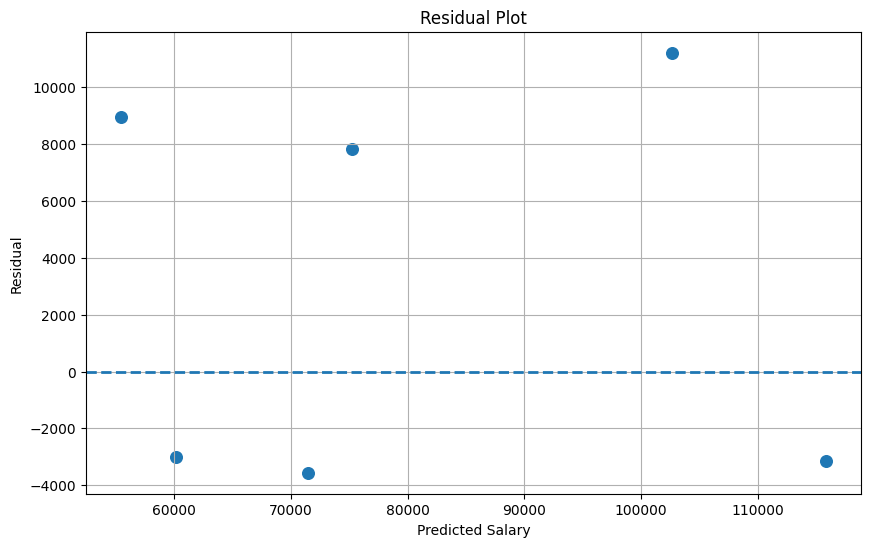

In [51]:
plt.figure(figsize=(10, 6))

plt.scatter(
    y_pred,
    residuals,
    s=70
)

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=2
)

plt.xlabel("Predicted Salary")
plt.ylabel("Residual")
plt.title("Residual Plot")

plt.grid(True)
plt.show()

##Residual Distribution

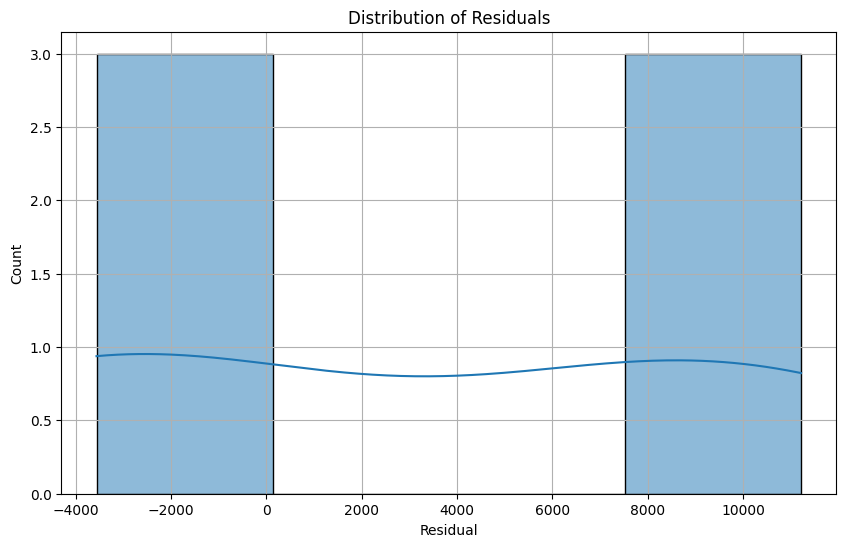

In [52]:
plt.figure(figsize=(10, 6))

sns.histplot(
    residuals,
    kde=True
)

plt.xlabel("Residual")
plt.title("Distribution of Residuals")

plt.grid(True)
plt.show()

##Check Mean Residual

In [53]:
print(f"Mean Residual: {residuals.mean():.2f}")

Mean Residual: 3047.72


##Test the Model with New Data

In [54]:
new_data = pd.DataFrame({
    "YearsExperience": [
        0.5,
        2,
        4,
        6,
        8,
        10,
        12
    ]
})

new_predictions = model.predict(new_data)

new_results = new_data.copy()

new_results["Predicted Salary"] = new_predictions

new_results

,YearsExperience,Predicted Salary
0,0.5,29092.109141
1,2.0,43227.832126
2,4.0,62075.462772
3,6.0,80923.093418
4,8.0,99770.724064
5,10.0,118618.354710
6,12.0,137465.985356


##Model Summary

In [55]:
print("=" * 50)
print("SIMPLE LINEAR REGRESSION SUMMARY")
print("=" * 50)

print(f"Coefficient (m): ₹{model.coef_[0]:,.2f}")
print(f"Intercept (b):   ₹{model.intercept_:,.2f}")

print("\nEquation:")
print(
    f"Salary = {model.coef_[0]:,.2f} × "
    f"YearsExperience + {model.intercept_:,.2f}"
)

print("\nTest Performance:")
print(f"MAE  : ₹{mae:,.2f}")
print(f"RMSE : ₹{rmse:,.2f}")
print(f"R²   : {r2:.4f}")

print("=" * 50)

SIMPLE LINEAR REGRESSION SUMMARY
Coefficient (m): ₹9,423.82
Intercept (b):   ₹24,380.20

Equation:
Salary = 9,423.82 × YearsExperience + 24,380.20

Test Performance:
MAE  : ₹6,286.45
RMSE : ₹7,059.04
R²   : 0.9024


# Part 3 Complete

We have now:

- Evaluated the model on unseen test data
- Calculated MAE
- Calculated MSE
- Calculated RMSE
- Calculated R²
- Compared actual and predicted salaries
- Calculated residuals
- Visualized residuals
- Tested new salary predictions
- Created a reusable prediction function

### Current Model

**Input:**

YearsExperience

↓

**Linear Regression**

↓

**Output:**

Predicted Salary

In the next part, we will move to **Multiple Linear Regression** and train a model using multiple independent features, followed by testing and comparison against our Simple Linear Regression model.

# Multiple Linear Regression

Simple Linear Regression:

y = mx + b

uses one input variable.

Multiple Linear Regression uses two or more input variables:

y = b₀ + b₁x₁ + b₂x₂ + ... + bₙxₙ

For our salary dataset:

Salary = b₀ + b₁(Age) + b₂(YearsExperience)

The model will learn:

- b₀ → Intercept
- b₁ → Age coefficient
- b₂ → Experience coefficient

## Multiple Regression Dataset

We will use a second real salary dataset containing multiple numerical predictors.

Features:

- Age
- Years of Experience

Target:

- Salary

Later, we can extend the model to categorical features such as Education Level and Job Title.

In [56]:
!mkdir -p /content/multiple_salary_dataset

!kaggle datasets download \
    -d mohithsairamreddy/salary-data \
    -p /content/multiple_salary_dataset \
    --unzip

Dataset URL: https://www.kaggle.com/datasets/mohithsairamreddy/salary-data
License(s): Community Data License Agreement - Sharing - Version 1.0
100% 16.6k/16.6k [00:00<00:00, 24.8MB/s]



In [57]:
os.listdir("/content/multiple_salary_dataset")

['Salary_Data.csv']

In [61]:
import os

csv_files = [
    file
    for file in os.listdir("/content/multiple_salary_dataset")
    if file.endswith(".csv")
]

csv_files

['Salary_Data.csv']

In [62]:
multiple_dataset_path = os.path.join(
    "/content/multiple_salary_dataset",
    csv_files[0]
)

multi_df = pd.read_csv(multiple_dataset_path)

multi_df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


##Inspect Dataset

In [63]:
print("Shape:", multi_df.shape)

print("\nColumns:")
print(multi_df.columns.tolist())

print("\nData Types:")
print(multi_df.dtypes)

Shape: (6704, 6)

Columns:
['Age', 'Gender', 'Education Level', 'Job Title', 'Years of Experience', 'Salary']

Data Types:
Age                    float64
Gender                  object
Education Level         object
Job Title               object
Years of Experience    float64
Salary                 float64
dtype: object


#Check Missing Values

In [64]:
multi_df.isnull().sum()

,0
Age,2
Gender,2
Education Level,3
Job Title,2
Years of Experience,3
Salary,5


#Check Duplicates

In [65]:
print("Duplicate rows:", multi_df.duplicated().sum())

Duplicate rows: 4912


#View Numerical Statistics

In [66]:
multi_df.describe()

,Age,Years of Experience,Salary
count,6702.000000,6701.000000,6699.000000
mean,33.620859,8.094687,115326.964771
std,7.614633,6.059003,52786.183911
min,21.000000,0.000000,350.000000
25%,28.000000,3.000000,70000.000000
50%,32.000000,7.000000,115000.000000
75%,38.000000,12.000000,160000.000000
max,62.000000,34.000000,250000.000000


#Select Numerical Features

## Selecting Features

For our first Multiple Linear Regression model, we'll use:

X₁ = Age

X₂ = Years of Experience

Target:

y = Salary

Therefore:

Salary = b₀ + b₁(Age) + b₂(YearsExperience)

In [67]:
features = [
    "Age",
    "Years of Experience"
]

target = "Salary"

X_multi = multi_df[features]
y_multi = multi_df[target]

print("Features:")
display(X_multi.head())

print("\nTarget:")
display(y_multi.head())

Features:


,Age,Years of Experience
0,32.0,5.0
1,28.0,3.0
2,45.0,15.0
3,36.0,7.0
4,52.0,20.0



Target:


,Salary
0,90000.0
1,65000.0
2,150000.0
3,60000.0
4,200000.0


#Remove Missing Values

In [68]:
multi_data = multi_df[features + [target]].dropna()

print("Original rows:", len(multi_df))
print("Rows after cleaning:", len(multi_data))

Original rows: 6704
Rows after cleaning: 6699


#Redefine X and y

In [69]:
X_multi = multi_data[features]
y_multi = multi_data[target]

print("X shape:", X_multi.shape)
print("y shape:", y_multi.shape)

X shape: (6699, 2)
y shape: (6699,)


#Train/Test Split

## Train/Test Split

We'll use:

- 80% → Training
- 20% → Testing

In [70]:
X_multi_train, X_multi_test, y_multi_train, y_multi_test = train_test_split(
    X_multi,
    y_multi,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(X_multi_train))
print("Testing samples:", len(X_multi_test))

Training samples: 5359
Testing samples: 1340


#Create Multiple Linear Regression Model

In [72]:
multi_model = LinearRegression()

#Train the Model

In [73]:
multi_model.fit(
    X_multi_train,
    y_multi_train
)

print("Multiple Linear Regression model trained.")

Multiple Linear Regression model trained.


#Get Coefficients

## Learned Coefficients

Our model has two coefficients:

- One for Age
- One for Years of Experience

The equation is:

Salary = b₀ + b₁(Age) + b₂(Experience)

In [74]:
print("Intercept:", multi_model.intercept_)

for feature, coefficient in zip(
    features,
    multi_model.coef_
):
    print(f"{feature}: {coefficient}")

Intercept: 97564.46438885226
Age: -1626.0028581307954
Years of Experience: 8956.543277146466


#Display the Complete Equation

In [75]:
b0 = multi_model.intercept_
b1 = multi_model.coef_[0]
b2 = multi_model.coef_[1]

print(
    f"Salary = {b0:.2f} "
    f"+ ({b1:.2f} × Age) "
    f"+ ({b2:.2f} × YearsExperience)"
)

Salary = 97564.46 + (-1626.00 × Age) + (8956.54 × YearsExperience)


#Make Predictions

In [76]:
y_multi_pred = multi_model.predict(X_multi_test)

print("First 10 predictions:")
print(y_multi_pred[:10])

First 10 predictions:
[ 74827.47948988 110680.70771332  80532.01705076  76453.48234801
  63845.19641878  89488.56032791  69949.47091548  99271.63259155
 146506.8808219   93567.09503066]


#Actual vs Predicted

In [77]:
multi_results = pd.DataFrame({
    "Age": X_multi_test["Age"].values,
    "YearsExperience": X_multi_test["Years of Experience"].values,
    "Actual Salary": y_multi_test.values,
    "Predicted Salary": y_multi_pred
})

multi_results["Error"] = (
    multi_results["Actual Salary"] -
    multi_results["Predicted Salary"]
)

multi_results["Absolute Error"] = (
    multi_results["Error"].abs()
)

multi_results.head(10)

,Age,YearsExperience,Actual Salary,Predicted Salary,Error,Absolute Error
0,25.0,2.0,90249.0,74827.479490,15421.520510,15421.520510
1,36.0,8.0,135000.0,110680.707713,24319.292287,24319.292287
2,27.0,3.0,80000.0,80532.017051,-532.017051,532.017051
3,24.0,2.0,64182.0,76453.482348,-12271.482348,12271.482348
4,29.0,1.5,40000.0,63845.196419,-23845.196419,23845.196419
5,27.0,4.0,140000.0,89488.560328,50511.439672,50511.439672
6,28.0,2.0,40000.0,69949.470915,-29949.470915,29949.470915
7,32.0,6.0,90000.0,99271.632592,-9271.632592,9271.632592
8,36.0,12.0,170000.0,146506.880822,23493.119178,23493.119178
9,30.0,5.0,145000.0,93567.095031,51432.904969,51432.904969


#Evaluate Multiple Regression

In [78]:
multi_mae = mean_absolute_error(
    y_multi_test,
    y_multi_pred
)

multi_mse = mean_squared_error(
    y_multi_test,
    y_multi_pred
)

multi_rmse = np.sqrt(multi_mse)

multi_r2 = r2_score(
    y_multi_test,
    y_multi_pred
)

print("=" * 45)
print("MULTIPLE LINEAR REGRESSION")
print("=" * 45)

print(f"MAE  : {multi_mae:,.2f}")
print(f"MSE  : {multi_mse:,.2f}")
print(f"RMSE : {multi_rmse:,.2f}")
print(f"R²   : {multi_r2:.4f}")

print("=" * 45)

MULTIPLE LINEAR REGRESSION
MAE  : 24,269.92
MSE  : 915,608,370.88
RMSE : 30,259.02
R²   : 0.6779


#Actual vs Predicted Visualization

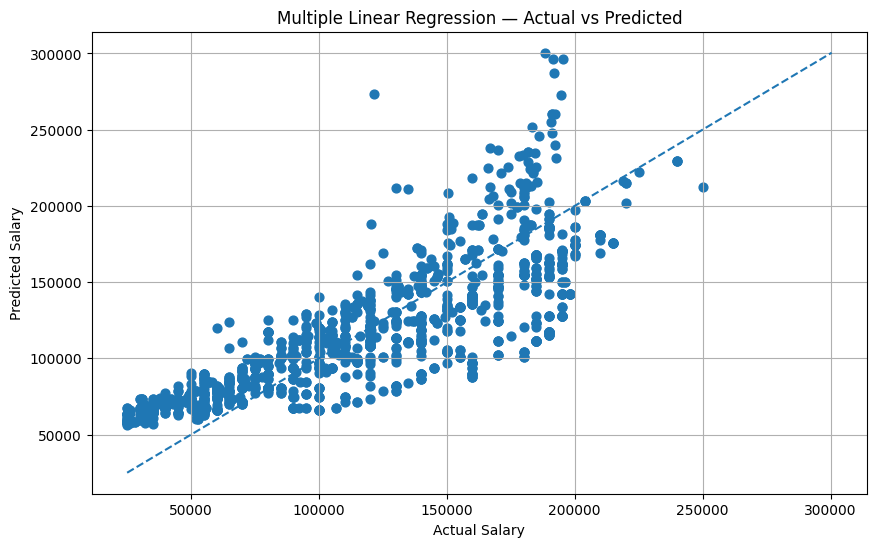

In [79]:
plt.figure(figsize=(10, 6))

plt.scatter(
    y_multi_test,
    y_multi_pred,
    s=40
)

min_value = min(
    y_multi_test.min(),
    y_multi_pred.min()
)

max_value = max(
    y_multi_test.max(),
    y_multi_pred.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Multiple Linear Regression — Actual vs Predicted")

plt.grid(True)
plt.show()

#Residual Analysis

In [80]:
multi_residuals = y_multi_test - y_multi_pred

print("Mean residual:", multi_residuals.mean())

Mean residual: -356.5591771841588


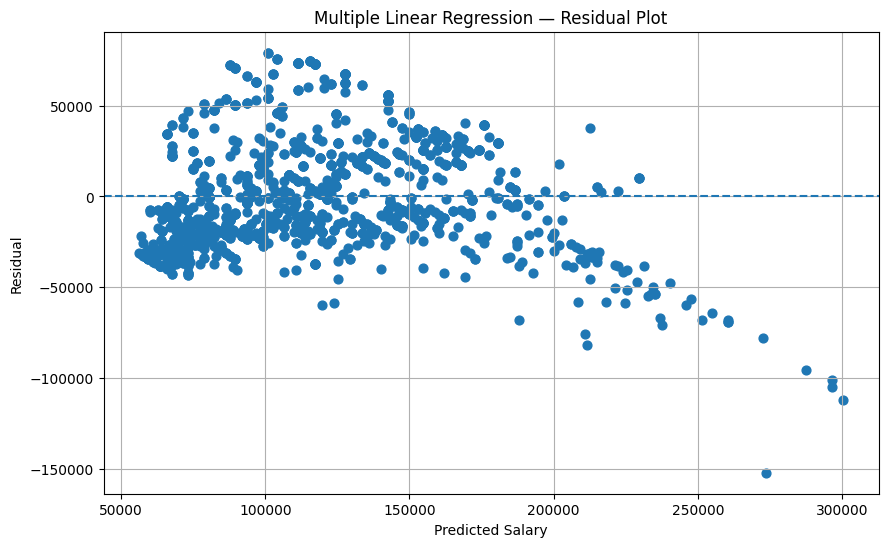

In [81]:
plt.figure(figsize=(10, 6))

plt.scatter(
    y_multi_pred,
    multi_residuals,
    s=40
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Salary")
plt.ylabel("Residual")
plt.title("Multiple Linear Regression — Residual Plot")

plt.grid(True)
plt.show()

#Test the Multiple Regression Model

In [82]:
new_employee = pd.DataFrame({
    "Age": [30],
    "Years of Experience": [5]
})

predicted_salary = multi_model.predict(new_employee)[0]

print(
    f"Predicted Salary: ₹{predicted_salary:,.2f}"
)

Predicted Salary: ₹93,567.10


#Test Multiple Employees

In [83]:
new_employees = pd.DataFrame({
    "Age": [25, 30, 35, 40, 45],
    "Years of Experience": [2, 5, 8, 12, 15]
})

predictions = multi_model.predict(new_employees)

new_employee_results = new_employees.copy()

new_employee_results["Predicted Salary"] = predictions

new_employee_results

,Age,Years of Experience,Predicted Salary
0,25,2,74827.479490
1,30,5,93567.095031
2,35,8,112306.710571
3,40,12,140002.869389
4,45,15,158742.484930


#Create Prediction Function

In [84]:
def predict_salary_multiple(age, years_experience):

    input_data = pd.DataFrame({
        "Age": [age],
        "Years of Experience": [years_experience]
    })

    prediction = multi_model.predict(input_data)[0]

    return prediction

#Test Prediction Function

In [85]:
age = 32
experience = 7

prediction = predict_salary_multiple(
    age,
    experience
)

print(f"Age: {age}")
print(f"Experience: {experience} years")
print(f"Predicted Salary: ₹{prediction:,.2f}")

Age: 32
Experience: 7 years
Predicted Salary: ₹108,228.18


#Test Multiple Cases

In [86]:
test_cases = [
    (25, 2),
    (30, 5),
    (35, 8),
    (40, 12),
    (45, 15),
    (50, 20)
]

test_predictions = []

for age, experience in test_cases:

    prediction = predict_salary_multiple(
        age,
        experience
    )

    test_predictions.append({
        "Age": age,
        "YearsExperience": experience,
        "Predicted Salary": prediction
    })

pd.DataFrame(test_predictions)

,Age,YearsExperience,Predicted Salary
0,25,2,74827.479490
1,30,5,93567.095031
2,35,8,112306.710571
3,40,12,140002.869389
4,45,15,158742.484930
5,50,20,195395.187025


# Simple vs Multiple Linear Regression

### Simple Linear Regression

Feature:

**YearsExperience**

Target:

**Salary**

### Multiple Linear Regression

Features:

**Age + YearsExperience**

Target:

**Salary**

We can now compare their performance on their respective test datasets.

Important:

These models use different datasets, so their raw error metrics should **not** be treated as a direct apples-to-apples model comparison. The comparison here is primarily to understand the workflow and the effect of multiple predictors.

In [87]:
comparison_metrics = pd.DataFrame({
    "Model": [
        "Simple Linear Regression",
        "Multiple Linear Regression"
    ],
    "Features": [
        "YearsExperience",
        "Age + YearsExperience"
    ],
    "MAE": [
        mae,
        multi_mae
    ],
    "RMSE": [
        rmse,
        multi_rmse
    ],
    "R²": [
        r2,
        multi_r2
    ]
})

comparison_metrics

,Model,Features,MAE,RMSE,R²
0,Simple Linear Regression,YearsExperience,6286.453831,7059.043622,0.902446
1,Multiple Linear Regression,Age + YearsExperience,24269.919097,30259.021314,0.677938


In [88]:
print("=" * 55)
print("MULTIPLE LINEAR REGRESSION SUMMARY")
print("=" * 55)

print(
    f"Intercept: {multi_model.intercept_:,.2f}"
)

for feature, coefficient in zip(
    features,
    multi_model.coef_
):
    print(
        f"{feature} coefficient: {coefficient:,.2f}"
    )

print("\nModel Equation:")
print(
    f"Salary = {b0:.2f} "
    f"+ {b1:.2f}(Age) "
    f"+ {b2:.2f}(YearsExperience)"
)

print("\nTest Metrics:")
print(f"MAE  : {multi_mae:,.2f}")
print(f"RMSE : {multi_rmse:,.2f}")
print(f"R²   : {multi_r2:.4f}")

print("=" * 55)

MULTIPLE LINEAR REGRESSION SUMMARY
Intercept: 97,564.46
Age coefficient: -1,626.00
Years of Experience coefficient: 8,956.54

Model Equation:
Salary = 97564.46 + -1626.00(Age) + 8956.54(YearsExperience)

Test Metrics:
MAE  : 24,269.92
RMSE : 30,259.02
R²   : 0.6779


# Part 4 Complete

We have now trained a genuine Multiple Linear Regression model using two real predictors:

**Age + Years of Experience → Salary**

We also:

- Downloaded a second real salary dataset
- Prepared multiple features
- Split the data
- Trained `LinearRegression()`
- Extracted coefficients
- Generated predictions
- Calculated MAE, MSE, RMSE and R²
- Analyzed residuals
- Tested new employees
- Created a reusable prediction function

